# Brent Oil Price EDA and Change Point Model Understanding

This notebook covers Task 1b of the analysis:
1. Loading and visualizing the raw Brent oil price series and its log returns.
2. Investigating trend, stationarity, and volatility properties, and discussing how they inform modeling choices.
3. Explaining the purpose and expected outputs of change point models for detecting structural breaks in oil prices.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_brent_series, load_key_events
from src.eda import adf_test, rolling_volatility, plot_price_series, plot_log_returns

plt.rcParams['figure.dpi'] = 100


## 1. Load data

In [2]:
series = load_brent_series(os.path.join('..', 'data', 'raw', 'BrentOilPrices.csv'))
prices = series.prices
log_returns = series.log_returns

events = load_key_events(os.path.join('..', 'data', 'events', 'key_events.csv'))

print(f"Price series: {len(prices):,} observations from {prices['Date'].min().date()} to {prices['Date'].max().date()}")
print(f"Loaded {len(events)} key events")
prices.head()


Price series: 9,927 observations from 1987-05-20 to 2026-07-06
Loaded 20 key events


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


## 2. Raw price series

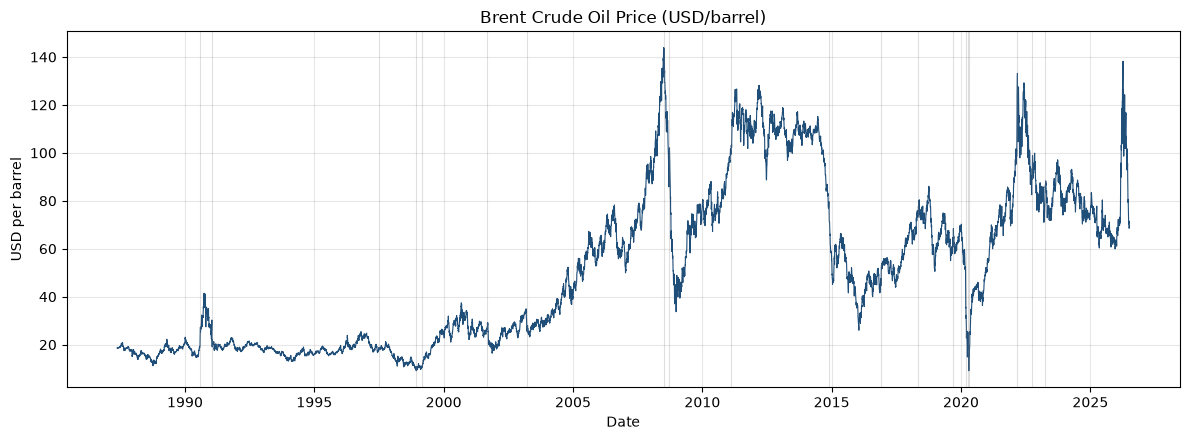

In [3]:
ax = plot_price_series(prices)
for _, ev in events.iterrows():
    ax.axvline(ev['date'], color='gray', alpha=0.25, linewidth=0.8)
plt.tight_layout()
plt.show()


The raw price series shows a clear long-run **non-stationary** pattern: sustained multi-year trends up and down (e.g., the run-up to the 2008 peak near $147/barrel, the 2014-2016 collapse, and the 2020 COVID-19 crash), rather than fluctuation around a fixed mean. This is typical of commodity prices and is the main reason we do not model the raw price level directly for change point / stationarity-based analysis -- instead we work with returns.

> **Takeaway -> modeling plan:** The raw price level is non-stationary, so it is not a valid input for a stationarity-assuming change point model. **Action:** model log returns (or a derived volatility proxy), not raw price, in the Bayesian change point step.

## 3. Log returns

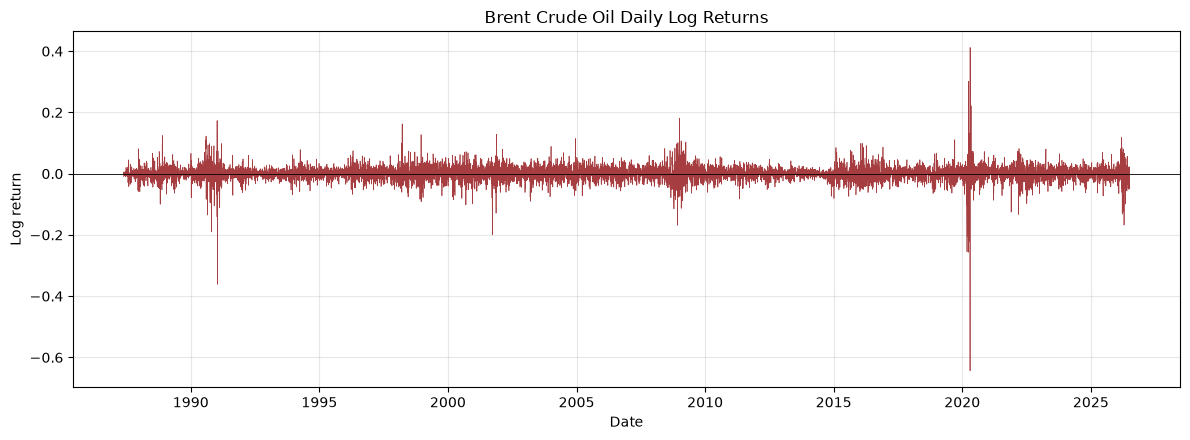

In [4]:
dates_for_returns = prices['Date']
ax = plot_log_returns(dates_for_returns, log_returns)
plt.tight_layout()
plt.show()


Log returns fluctuate around zero with no obvious long-run trend, which is the behavior we want for stationarity-based modeling. However, the *magnitude* of fluctuations is clearly not constant over time -- there are visible clusters of large swings (e.g., around 2008-2009, 2014-2016, and 2020) separated by calmer periods. This pattern is known as **volatility clustering** and motivates modeling the variance, not just the mean, as something that can shift at change points.

> **Takeaway -> modeling plan:** Log returns look roughly mean-zero and stable in level, but their spread is visibly time-varying (volatility clustering). **Action:** the Bayesian change point model should allow the *variance* parameter to switch at a change point, not only the mean -- a mean-only switch model would miss the dominant pattern in this series.

## 4. Stationarity: Augmented Dickey-Fuller tests

In [5]:
price_adf = adf_test(prices['Price'], name='Raw price level')
returns_adf = adf_test(log_returns, name='Log returns')

pd.DataFrame([price_adf, returns_adf]).set_index('name')


,adf_statistic,p_value,n_obs,is_stationary_at_5pct
name,,,,
Raw price level,-2.517286,1.113248e-01,9897,False
Log returns,-16.947540,9.515136e-30,9895,True


**Interpretation.** The ADF test's null hypothesis is that the series has a unit root (is non-stationary). We expect the raw price level to fail to reject this null (p-value well above 0.05), confirming it is non-stationary, while the log-return series should strongly reject the null (very small p-value), confirming it is stationary. This is the standard justification in financial time series analysis for modeling returns rather than price levels: change point and volatility models generally assume (approximate) stationarity of the underlying process between regimes, which raw prices do not satisfy but returns approximately do.

> **Takeaway -> modeling plan:** The ADF test confirms prices are non-stationary (fail to reject unit root) while log returns are stationary (reject unit root). **Action:** this is the quantitative justification for choosing log returns as the series fed into the change point model -- using the non-stationary price series would violate the model's stationarity-within-regime assumption and could produce spurious change points driven purely by long-run trend.

## 5. Volatility patterns

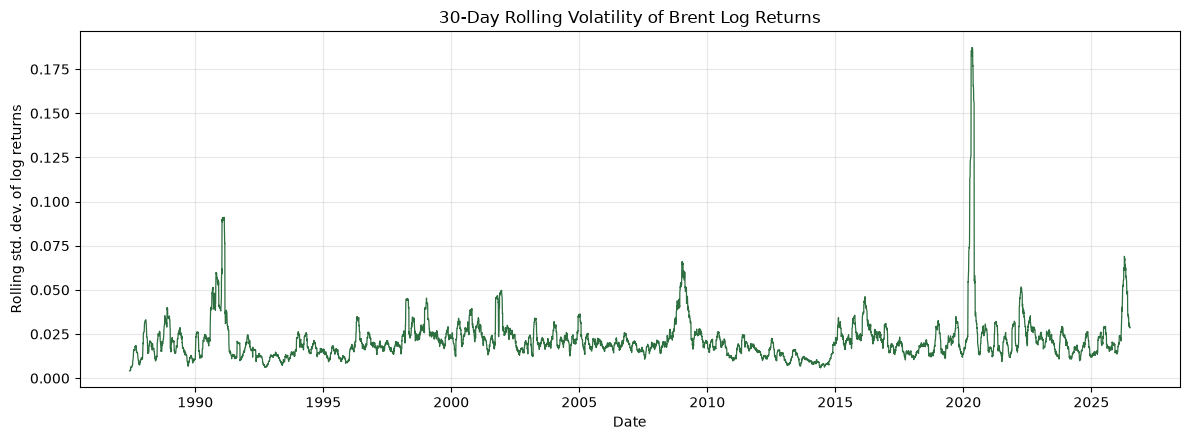

In [6]:
vol_30d = rolling_volatility(log_returns, window=30)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(dates_for_returns, vol_30d, color='#2e6f40', linewidth=0.9)
ax.set_title('30-Day Rolling Volatility of Brent Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling std. dev. of log returns')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Rolling volatility is itself highly variable over time, with pronounced spikes during the 2008-2009 financial crisis, the 2014-2016 oil price collapse, and the 2020 COVID-19 / price-war period. These spikes align approximately with several entries in `data/events/key_events.csv`, which is exactly the kind of visual evidence that motivates a formal change point analysis rather than eyeballing the chart: we want a principled, reproducible way to locate *where* the volatility (and mean) regime actually shifts, rather than relying on the human eye.

> **Takeaway -> modeling plan:** Rolling volatility spikes are visually aligned with several dated events in `data/events/key_events.csv` (e.g., 2008-2009, 2014-2016, 2020). **Action:** use this rolling-volatility series as a first-pass sanity check against the Bayesian change point model's detected break dates before trusting the model's output -- large discrepancies would flag a modeling issue (e.g., wrong penalty/prior) rather than a genuine new finding.

## 6. What trend, stationarity, and volatility tell us about modeling choices

- **Trend / non-stationarity of price levels** means we should not fit models that assume a constant mean (e.g., a plain Gaussian change-in-mean model) directly to raw prices -- we either difference/log-transform the series first, or use models designed for trending data (e.g., local-level/local-trend state-space models).
- **Stationarity of log returns** supports using returns as the primary series for change point detection, since most standard change point frameworks (Bayesian change point models, CUSUM, PELT) assume the data are stationary within each regime.
- **Volatility clustering** means a single 'change in mean' model on returns is not enough -- we likely need to detect **changes in variance** as well as (or instead of) changes in mean, since large regime shifts in oil markets often show up primarily as a jump in volatility rather than a persistent shift in the average daily return.
- Together, these properties argue for a change point model applied to log returns (or a volatility proxy such as squared/absolute returns) that can flag shifts in both level and variance, rather than a naive model applied to the raw price series.

## 7. Purpose and expected outputs of change point models

**Purpose.** Change point models are designed to automatically detect the point(s) in time at which the statistical properties of a time series -- its mean, variance, trend, or autocorrelation structure -- change significantly, without requiring the analyst to specify the timing in advance. For Brent oil prices, this means detecting the dates around which the price process shifted from one 'regime' (e.g., a period of low volatility and stable prices) to another (e.g., a period of high volatility driven by a supply shock or financial crisis). Two broad families are relevant here:

- **Frequentist / search-based methods** (e.g., PELT and binary segmentation, as implemented in the `ruptures` library) search for the set of breakpoints that best partitions the series into segments with different means/variances, typically balancing model fit against a penalty for adding more change points.
- **Bayesian change point models** treat the number and location of change points as unknown parameters with prior distributions, and infer a posterior distribution over change point locations (and pre-/post-change parameters) given the data -- for example, using MCMC sampling (e.g., with PyMC). This naturally produces **uncertainty estimates** (credible intervals) around each detected change point, not just a single date.

**Expected outputs.**
- One or more **estimated change point dates** (or date ranges, in the Bayesian case, expressed as a posterior distribution/credible interval rather than a single exact day).
- **Pre-change and post-change parameter estimates** for each detected regime -- e.g., the mean daily log return and volatility (standard deviation of returns) before vs. after each change point.
- A **quantified magnitude of change** (e.g., percentage change in average volatility across the break), which can then be compared against the compiled event dataset to see which known events fall near which detected breaks.

**Inherent limitations.**
- Change point models detect *statistical* breaks in the data; they do not, by themselves, explain *why* a break occurred. Linking a detected change point to a specific event in `data/events/key_events.csv` is an **association**, not a proof of causation -- see `docs/assumptions_and_limitations.md` for a full discussion.
- Results are sensitive to the choice of algorithm, penalty/prior parameters, and the series used (raw price vs. log return vs. a volatility proxy); different reasonable choices can yield different sets of detected change points.
- If two events occur close together in time (as is common for financial-crisis-era oil markets), a single detected change point may plausibly correspond to more than one candidate event.


## Next steps

This notebook covers EDA and conceptual grounding only. The next phase of the project will implement a change point model on the log-return (and/or volatility) series, compare detected change points against `data/events/key_events.csv`, and summarize findings for stakeholders, subject to the assumptions and limitations documented in `docs/assumptions_and_limitations.md`.